# Anexo: ¿se puede mejorar el resultado cambiando el preprocesamiento?

**Aprendizaje Automático 1 — Tecnicatura en Inteligencia Artificial (FCEIA, UNR)**

**Integrantes:** Calabozo · Darruiz · Di Carlo · Giuntoli

---

En el trabajo principal (`TP-regresion-AA1.ipynb`) imputamos con la mediana y escalamos con
`StandardScaler`, y el mejor modelo llegó a un R² de prueba de 0.36. Acá probamos si otras formas de
imputar, escalar o buscar hiperparámetros mejoran ese resultado.

Usamos la misma división y la misma semilla, comparamos con el **RMSE de validación cruzada de 5
particiones** y cambiamos una sola cosa por vez.

In [1]:
# Mismas bibliotecas que el trabajo principal, más los transformadores que
# queremos probar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (StandardScaler, RobustScaler, MinMaxScaler,
                                   PowerTransformer, QuantileTransformer,
                                   PolynomialFeatures)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (mean_squared_error, root_mean_squared_error,
                             mean_absolute_error, r2_score)

SEMILLA = 42
sns.set_theme(style='whitegrid')

In [2]:
# Reproducimos exactamente la preparación del trabajo principal
datos = (pd.read_csv('data/house-prices-tp.csv')
         .dropna(subset=['MEDV']).reset_index(drop=True))

X = datos.drop(columns='MEDV')
y = datos['MEDV']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA)

# Configuración de referencia: la del trabajo principal
REFERENCIA = [('imputador', SimpleImputer(strategy='median')),
              ('escalador', StandardScaler())]

print(f'Entrenamiento: {len(X_train)} filas   Prueba: {len(X_test)} filas')
print('Celdas faltantes en las características de entrenamiento: '
      f'{X_train.isna().mean().mean() * 100:.1f} %')

Entrenamiento: 428 filas   Prueba: 107 filas
Celdas faltantes en las características de entrenamiento: 1.6 %


## 1. ¿Cambia algo imputar de otra manera?

Comparamos la mediana (la del trabajo principal) con la media y con `KNNImputer` para distintos
valores de `k`.

In [3]:
# Probamos cada imputador dejando fijos el escalador y el modelo
imputadores = {
    'Mediana (referencia)': SimpleImputer(strategy='median'),
    'Media': SimpleImputer(strategy='mean'),
    'KNN (k=3)': KNNImputer(n_neighbors=3),
    'KNN (k=5)': KNNImputer(n_neighbors=5),
    'KNN (k=10)': KNNImputer(n_neighbors=10),
}

tabla = []
for nombre, imputador in imputadores.items():
    flujo = Pipeline([('imputador', imputador),
                      ('escalador', StandardScaler()),
                      ('regresor', Ridge(alpha=17.78))])
    puntajes = cross_val_score(flujo, X_train, y_train, cv=5,
                               scoring='neg_root_mean_squared_error')
    tabla.append({'Imputador': nombre, 'RMSE (CV)': -puntajes.mean(),
                  'Desvío entre particiones': puntajes.std()})

resultados_imputacion = pd.DataFrame(tabla)
display(resultados_imputacion.round(3))

,Imputador,RMSE (CV),Desvío entre particiones
0,Mediana (referencia),5.813,1.085
1,Media,5.779,1.062
2,KNN (k=3),5.757,1.010
3,KNN (k=5),5.755,1.049
4,KNN (k=10),5.812,1.103


Las diferencias son **muy chicas**: entre la mejor opción (5.755) y la peor (5.813) hay menos de
0.06 k\$, contra un desvío entre particiones de alrededor de 1 k\$. Los faltantes son apenas el
1.6 % de las celdas de entrenamiento, así que el imputador tiene poco margen para cambiar el
resultado. **La mediana alcanza.**

## 2. ¿Cambia algo escalar de otra manera?

Comparamos no escalar, tres escaladores lineales (`StandardScaler`, `RobustScaler`, `MinMaxScaler`)
y dos transformaciones no lineales (`PowerTransformer`, `QuantileTransformer`), con
`LinearRegression` y con Ridge.

In [4]:
# ¿Afecta el escalador a LinearRegression? 'passthrough' significa no escalar
escaladores = {
    'Sin escalar': 'passthrough',
    'StandardScaler (lineal)': StandardScaler(),
    'RobustScaler (lineal)': RobustScaler(),
    'MinMaxScaler (lineal)': MinMaxScaler(),
    'PowerTransformer (NO lineal)': PowerTransformer(),
    # n_quantiles no puede superar la cantidad de filas de cada partición
    'QuantileTransformer (NO lineal)': QuantileTransformer(
        output_distribution='normal', n_quantiles=200, random_state=SEMILLA),
}

tabla = []
for nombre, escalador in escaladores.items():
    fila = {'Escalador': nombre}
    for modelo_nombre, modelo in [('LinearRegression', LinearRegression()),
                                  ('Ridge (α=17.8)', Ridge(alpha=17.78))]:
        flujo = Pipeline([('imputador', SimpleImputer(strategy='median')),
                          ('escalador', escalador), ('regresor', modelo)])
        puntajes = cross_val_score(flujo, X_train, y_train, cv=5,
                                   scoring='neg_root_mean_squared_error')
        # Mostramos 6 decimales para que se vea que los lineales coinciden
        # exactamente
        fila[f'RMSE CV — {modelo_nombre}'] = -puntajes.mean()
    tabla.append(fila)

resultados_escalado = pd.DataFrame(tabla)
display(resultados_escalado.round(6))

,Escalador,RMSE CV — LinearRegression,RMSE CV — Ridge (α=17.8)
0,Sin escalar,5.828958,5.910616
1,StandardScaler (lineal),5.828958,5.813316
2,RobustScaler (lineal),5.828958,5.850847
3,MinMaxScaler (lineal),5.828958,6.698081
4,PowerTransformer (NO lineal),5.466001,5.483602
5,QuantileTransformer (NO lineal),5.599520,5.608515


- Con **`LinearRegression`**, no escalar y los tres escaladores lineales dan **exactamente el mismo
  RMSE** (5.828958): cambiar la escala de una variable solo cambia su coeficiente, no las
  predicciones.
- Con **Ridge** sí cambian, porque la penalización depende del tamaño de los coeficientes;
  `MinMaxScaler` es el peor (6.698).
- Las transformaciones **no lineales** mejoran los dos modelos (`PowerTransformer`: 5.466 y 5.484).

## 3. Efecto de `PowerTransformer`

`PowerTransformer` estima para cada variable un exponente `λ` que la acerca a una distribución
simétrica, y además la estandariza. Lo vemos sobre `CRIM`, la variable más asimétrica, y `DIS`, con
asimetría moderada:

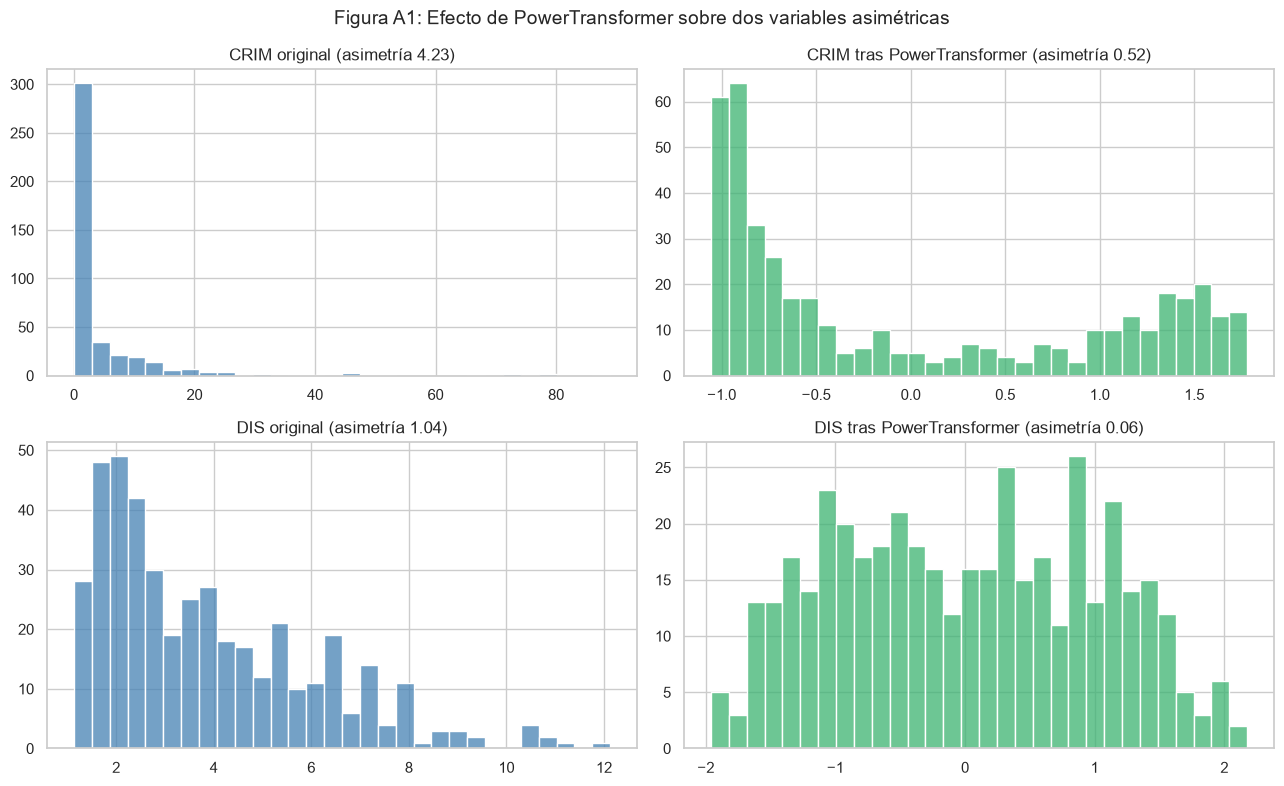

Exponente λ estimado para cada variable:
CHAS      -21.292
NOX        -3.550
ZN         -0.826
CRIM       -0.773
TAX        -0.442
DIS        -0.415
RAD        -0.345
LSTAT       0.179
INDUS       0.423
RM          0.681
AGE         1.302
B           3.273
PTRATIO     4.478


In [5]:
# Cómo cambia la forma de dos variables asimétricas al aplicar
# PowerTransformer
X_train_imputado = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(X_train),
    columns=X.columns)

transformador = PowerTransformer().fit(X_train_imputado)
X_train_transformado = pd.DataFrame(transformador.transform(X_train_imputado),
                                    columns=X.columns)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for fila, variable in enumerate(['CRIM', 'DIS']):
    sns.histplot(X_train_imputado[variable], bins=30, ax=axes[fila, 0],
                 color='steelblue')
    asimetria = X_train_imputado[variable].skew()
    axes[fila, 0].set_title(f'{variable} original '
                            f'(asimetría {asimetria:.2f})')
    sns.histplot(X_train_transformado[variable], bins=30, ax=axes[fila, 1],
                 color='mediumseagreen')
    asimetria = X_train_transformado[variable].skew()
    axes[fila, 1].set_title(f'{variable} tras PowerTransformer '
                            f'(asimetría {asimetria:.2f})')
    for ax in axes[fila]:
        ax.set_xlabel('')
        ax.set_ylabel('')

fig.suptitle('Figura A1: Efecto de PowerTransformer sobre dos variables '
             'asimétricas', fontsize=14)
fig.tight_layout()
plt.show()

# Lambda estimado para cada variable
lambdas = pd.Series(transformador.lambdas_, index=X.columns).sort_values()
print('Exponente λ estimado para cada variable:')
print(lambdas.round(3).to_string())

En la **Figura A1**, la asimetría de `DIS` baja de 1.04 a 0.06 y la de `CRIM` de 4.23 a 0.52, aunque
`CRIM` queda dividida en dos grupos por la acumulación de valores cercanos a cero.

Las variables asimétricas a la derecha reciben `λ < 1` (`CRIM` −0.77, `ZN` −0.83, `DIS` −0.42), que
comprime la cola larga, y las asimétricas a la izquierda `λ > 1` (`PTRATIO` 4.48, `B` 3.27, `AGE`
1.30). `CHAS`, que es binaria, recibe un valor extremo (−21.3), pero sigue teniendo solo dos
valores.

La mejora es coherente con lo que vimos en el trabajo principal: algunas relaciones con el precio
son curvas (Figura 3), y comprimir las colas las vuelve más lineales. El costo es que los
coeficientes dejan de estar en las unidades originales.

## 4. ¿Alcanza con afinar la búsqueda de hiperparámetros?

Probamos una grilla de `alpha` mucho más fina (200 valores en lugar de 25) y una búsqueda conjunta
de imputador, escalador y `alpha`.

In [6]:
# Búsqueda 1: solo alpha, pero con una grilla de 200 valores en lugar de 25
flujo = Pipeline(REFERENCIA + [('regresor', Ridge())])
busqueda_fina = GridSearchCV(flujo,
                             {'regresor__alpha': np.logspace(-2, 3, 200)},
                             cv=5, scoring='neg_root_mean_squared_error')
busqueda_fina.fit(X_train, y_train)

print('Grilla de 200 valores de alpha (solo cambia el hiperparámetro):')
print('   mejor alpha = '
      f'{busqueda_fina.best_params_["regresor__alpha"]:.3f}   '
      f'RMSE (CV) = {-busqueda_fina.best_score_:.4f}')
print('   trabajo principal, grilla de 25 valores: '
      'alpha = 17.783   RMSE (CV) = 5.8132')

Grilla de 200 valores de alpha (solo cambia el hiperparámetro):
   mejor alpha = 13.826   RMSE (CV) = 5.8125
   trabajo principal, grilla de 25 valores: alpha = 17.783   RMSE (CV) = 5.8132


In [7]:
# Búsqueda 2: GridSearchCV elige imputador, escalador y alpha al mismo tiempo
flujo = Pipeline([('imputador', SimpleImputer()),
                  ('escalador', StandardScaler()),
                  ('regresor', Ridge())])

grilla = {
    'imputador': [SimpleImputer(strategy='median'), KNNImputer(n_neighbors=3)],
    'escalador': [StandardScaler(), PowerTransformer()],
    'regresor__alpha': np.logspace(-2, 3, 30),
}

busqueda_conjunta = GridSearchCV(flujo, grilla, cv=5,
                                 scoring='neg_root_mean_squared_error')
busqueda_conjunta.fit(X_train, y_train)

print('Búsqueda conjunta de imputador + escalador + alpha:')
for parametro, valor in busqueda_conjunta.best_params_.items():
    print(f'   {parametro} = {valor}')
print(f'   RMSE (CV) = {-busqueda_conjunta.best_score_:.4f}')

Búsqueda conjunta de imputador + escalador + alpha:
   escalador = PowerTransformer()
   imputador = SimpleImputer(strategy='median')
   regresor__alpha = 2.592943797404667
   RMSE (CV) = 5.4648


La grilla fina casi no cambia nada (5.8125 frente a 5.8132), como era de esperar por la curva plana
de la Figura 11 del trabajo principal. La búsqueda conjunta sí mejora (5.4648), pero porque elige
`PowerTransformer`, no por el `alpha`.

## 5. Comparación final

Juntamos las variantes y agregamos una con **términos cuadráticos** (`PolynomialFeatures(2)`). Como
ya no es regresión lineal múltiple sobre las variables originales, queda fuera del alcance del
trabajo; la incluimos solo para medir cuánto pesa la no linealidad.

In [8]:
# Cada variante cambia una pieza; el modelo y el alpha quedan fijos para
# poder comparar
variantes = {
    'Referencia: mediana + StandardScaler': REFERENCIA,
    'KNN(3) + StandardScaler': [('imputador', KNNImputer(n_neighbors=3)),
                                ('escalador', StandardScaler())],
    'Mediana + PowerTransformer': [
        ('imputador', SimpleImputer(strategy='median')),
        ('escalador', PowerTransformer())],
    'KNN(3) + PowerTransformer': [('imputador', KNNImputer(n_neighbors=3)),
                                  ('escalador', PowerTransformer())],
    'Referencia + términos cuadráticos': REFERENCIA + [
        ('polinomios', PolynomialFeatures(2, include_bias=False)),
        ('escalador2', StandardScaler())],
}

tabla = []
for nombre, pasos in variantes.items():
    flujo = Pipeline(pasos + [('regresor', Ridge(alpha=17.78))])
    puntajes = cross_val_score(flujo, X_train, y_train, cv=5,
                               scoring='neg_root_mean_squared_error')
    pred_test = flujo.fit(X_train, y_train).predict(X_test)
    tabla.append({
        'Variante': nombre,
        'RMSE (CV)': -puntajes.mean(),
        'MSE (Test)': mean_squared_error(y_test, pred_test),
        'RMSE (Test)': root_mean_squared_error(y_test, pred_test),
        'MAE (Test)': mean_absolute_error(y_test, pred_test),
        'R² (Test)': r2_score(y_test, pred_test),
    })

comparacion = pd.DataFrame(tabla)
display(comparacion.round(3))

,Variante,RMSE (CV),MSE (Test),RMSE (Test),MAE (Test),R² (Test)
0,Referencia: mediana + StandardScaler,5.813,53.645,7.324,4.530,0.355
1,KNN(3) + StandardScaler,5.757,47.076,6.861,4.381,0.434
2,Mediana + PowerTransformer,5.484,44.365,6.661,4.187,0.467
3,KNN(3) + PowerTransformer,5.496,38.978,6.243,4.100,0.531
4,Referencia + términos cuadráticos,4.888,35.157,5.929,3.286,0.577


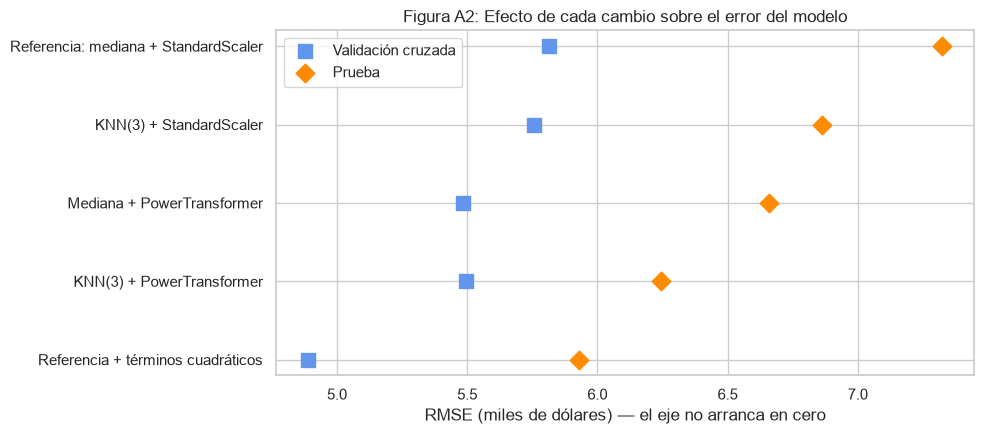

In [9]:
# Comparación visual de las dos estimaciones del error
posiciones = np.arange(len(comparacion))[::-1]

plt.figure(figsize=(10, 4.5))
plt.scatter(comparacion['RMSE (CV)'], posiciones, marker='s', s=90,
            color='cornflowerblue', label='Validación cruzada', zorder=3)
plt.scatter(comparacion['RMSE (Test)'], posiciones, marker='D', s=90,
            color='darkorange', label='Prueba', zorder=3)
plt.yticks(posiciones, comparacion['Variante'])
plt.xlabel('RMSE (miles de dólares) — el eje no arranca en cero')
plt.title('Figura A2: Efecto de cada cambio sobre el error del modelo')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Conclusiones del anexo

Según la **Figura A2** y la sección 4:

1. **Imputador:** mejora despreciable (de 5.81 a 5.76).
2. **Escalador:** los lineales no cambian nada con `LinearRegression`; `PowerTransformer` sí mejora
   (de 5.81 a 5.48, y el R² de prueba de 0.36 a 0.47).
3. **Términos cuadráticos:** es lo que más mejora (4.89, con un R² de prueba de 0.58).
4. **Grilla de `alpha` más fina:** no aporta nada.

Las dos mejoras atacan la **no linealidad**, lo que confirma el diagnóstico del trabajo principal:
el límite está en la forma del modelo, no en el preprocesamiento ni en los hiperparámetros. Aun así,
mantenemos mediana + `StandardScaler` porque es lo más simple, se interpreta directamente y respeta
el modelo que pide la consigna.